# Amazon 配送營運分析

本 notebook 使用公開 Kaggle 資料集模擬營運分析，目的在展示如何從模糊問題出發，逐步定義 KPI、驗證假設並形成下一步決策。這不是 Amazon 委託的分析，也不代表 Amazon 的實際營運狀況。

## 1. Business Problem｜營運問題

團隊發現部分配送耗時過長。由於營運資源有限，需要找出與較長配送時間相關的可能因素，並優先改善最具影響力的配送環節。

## 2. Analytical Question｜分析問題

為了把模糊的營運問題轉成可回答的分析問題，依序拆解為：

1. **配送時間較長的紀錄集中在哪裡？** 比較不同 Area、Traffic、Pickup Period、Distance、Weather 與 Category 的配送時間。
2. **觀察到的群組差異是否具有實質意義？** 同時檢查樣本數、平均數、中位數、IQR 與長時間配送比例，而不只看統計顯著性。
3. **最明顯的區域差異能否由已知因素解釋？** 針對 Semi-Urban 依序檢查 Distance、Traffic、Pickup Period 與 Category。
4. **納入其他已觀察因素後，哪些關聯仍然存在？** 使用多變量分析檢查 Area、Traffic、Pickup Period 與 Distance 的關聯是否穩定。
5. **哪個因素最值得優先採取下一步行動？** 綜合差異大小、樣本數、結果穩定性與營運可介入性，決定優先調查項目或未來的小規模實驗。

本分析的用途是安排後續調查的優先順序，不是證明因果關係。資料屬於靜態觀察資料，而且缺少 route design、order volume、agent availability、promised delivery time 與 pickup waiting time 等可能解釋。

## 3. KPI｜指標定義

**主要 KPI：`Delivery_Time`**

以分鐘衡量每筆配送耗時。群組比較同時使用平均數、中位數、IQR 與完整分布，避免只依賴平均數。

**輔助指標：Long-Duration Delivery Rate**

暫時將高於 `Delivery_Time` 第 75 百分位的紀錄定義為長時間配送，用來比較不同群組的長時間配送比例。資料沒有 SLA 或 promised ETA，因此這個門檻不能解讀為逾期配送標準。

## 4. Data Quality Summary｜資料品質摘要

完整清理邏輯放在 `src/data_preparation.py`。Notebook 只保留會影響分析判斷的品質問題與處理結果。原始資料不會被覆寫，也不對缺失值進行推補。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython import get_ipython
from IPython.display import display
from scipy.stats import kruskal, norm, spearmanr

from src.data_preparation import (
    add_analysis_features,
    audit_raw_data,
    clean_delivery_data,
)

if get_ipython() is not None:
    get_ipython().run_line_magic("matplotlib", "inline")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

raw_df = pd.read_csv("raw/amazon_delivery.csv")
raw_audit, raw_missing = audit_raw_data(raw_df)
cleaned_df, cleaning_log = clean_delivery_data(raw_df)
df, long_delivery_threshold, feature_quality = add_analysis_features(cleaned_df)

In [2]:
data_quality_summary = pd.DataFrame([
    ["資料規模", f"{len(raw_df):,} 筆、{raw_df.shape[1]} 欄", "保留原始資料，清理副本"],
    ["Order_ID 重複", int(raw_df["Order_ID"].duplicated().sum()), "沒有需要移除的重複 ID"],
    ["原生缺失值", "Rating 54；Weather 91", "依後續分析所需欄位個別排除"],
    ["文字形式缺失值", int(cleaning_log["Text placeholders converted to missing"]), "統一轉為真正缺失值"],
    ["超出 1–5 的 Rating", int(cleaning_log["Invalid ratings converted to missing"]), "Rating 設為缺失，保留配送紀錄"],
    ["跨午夜 Pickup_Time", int(cleaning_log["Pickup timestamps rolled into the next day"]), "Pickup timestamp 增加一天"],
    ["零原點座標", int(cleaning_log["Zero-origin coordinate records flagged"]), "保留配送紀錄，排除於距離分析"],
    ["座標符號不一致", int(cleaning_log["Coordinate sign-mismatch records flagged"]), "保留配送紀錄，排除於距離分析"],
    ["清理後資料", f"{len(df):,} 筆", "沒有因局部欄位問題刪除整筆資料"],
    ["長時間配送門檻", f"> {long_delivery_threshold:.0f} 分鐘", "分析用門檻，不是 SLA"],
], columns=["品質問題", "發現", "處理方式"])

display(data_quality_summary)

,品質問題,發現,處理方式
0,資料規模,"43,739 筆、16 欄",保留原始資料，清理副本
1,Order_ID 重複,0,沒有需要移除的重複 ID
2,原生缺失值,Rating 54；Weather 91,依後續分析所需欄位個別排除
3,文字形式缺失值,182,統一轉為真正缺失值
4,超出 1–5 的 Rating,53,Rating 設為缺失，保留配送紀錄
5,跨午夜 Pickup_Time,828,Pickup timestamp 增加一天
6,零原點座標,3505,保留配送紀錄，排除於距離分析
7,座標符號不一致,188,保留配送紀錄，排除於距離分析
8,清理後資料,"43,739 筆",沒有因局部欄位問題刪除整筆資料
9,長時間配送門檻,> 160 分鐘,分析用門檻，不是 SLA


資料清理後保留全部 43,739 筆配送紀錄。Rating、Weather 或 Traffic 的缺失不會導致資料被全域刪除；每項分析只排除其必要欄位不完整的紀錄。距離分析則只使用通過座標品質檢查的 40,046 筆紀錄。

### Delivery Time Distribution｜KPI 分布

下圖呈現主要 KPI `Delivery_Time` 的整體分布，以及本分析使用的中位數與長時間配送門檻。

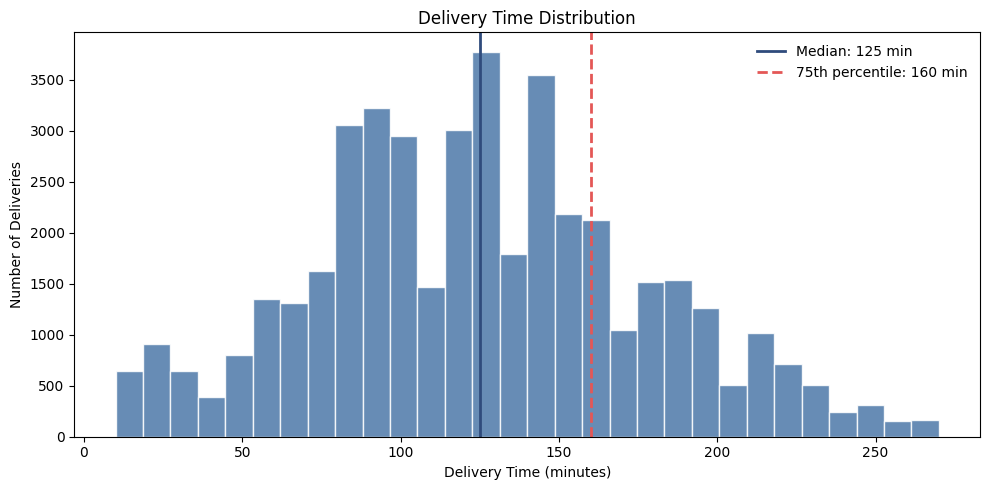

In [3]:
# Show the KPI distribution and the analytical threshold.
fig, axis = plt.subplots(figsize=(10, 5))
axis.hist(df["Delivery_Time"], bins=30, color="#4C78A8", alpha=0.85, edgecolor="white")
axis.axvline(df["Delivery_Time"].median(), color="#2F4B7C", linewidth=2, label=f"Median: {df['Delivery_Time'].median():.0f} min")
axis.axvline(long_delivery_threshold, color="#E45756", linewidth=2, linestyle="--", label=f"75th percentile: {long_delivery_threshold:.0f} min")
axis.set_title("Delivery Time Distribution")
axis.set_xlabel("Delivery Time (minutes)")
axis.set_ylabel("Number of Deliveries")
axis.legend(frameon=False)
plt.tight_layout()
plt.show()

`Delivery_Time` 的中位數為 125 分鐘，第 75 百分位為 160 分鐘。因此，本分析將超過 160 分鐘的紀錄暫時定義為長時間配送，用於比較各群組的長時間配送比例；這不是正式的 SLA 或逾期標準。

## 5. Hypothesis Framework｜分析假設

| 假設 | 可能機制 | 觀察欄位 | 如果成立，可能行動 |
|---|---|---|---|
| H1：距離越長，配送時間可能越長 | 行駛時間隨路程增加 | Distance、Delivery Time | 檢查 route design 與路線分配 |
| H2：下午或晚間可能較慢 | 交通、需求或可用運能不同 | Pickup Period、Traffic、Delivery Time | 檢查時段運能與 dispatch 規則 |
| H3：Semi-Urban 可能較慢 | 交通組成、路線或區域流程不同 | Area、Traffic、Distance、Delivery Time | 優先進行區域層級診斷 |
| H4：商品類別可能影響耗時 | pickup handling 流程不同 | Category、Delivery Time | 確認不同商品是否使用不同流程 |
| H5：天氣可能影響耗時 | 路況與行駛速度改變 | Weather、Delivery Time | 作為 capacity rule 或模型調整因素 |

Pickup Period 相關的運能配置與 route-related Distance 可透過營運決策部分調整；Area 與 Traffic 用來定位應優先介入的情境。Weather 與 Category 則主要作為背景與調整因素，但營運團隊仍可改善對不同天氣或商品類別的應對流程。

## 6. 關鍵群組比較

### 6.1 候選分組因素篩選

本階段比較五個候選分組因素：`Area`、`Traffic`、`Pickup Period`、`Category` 與 `Weather`。`Distance` 是連續變數，會在下一節另外分析。

篩選表使用 `usable_records` 與 `groups` 說明資料基礎；`mean_gap_minutes` 表示平均營運負擔差距，`median_gap_minutes` 表示典型配送時間差距，`long_duration_rate_gap_pp` 表示長時間配送比例的百分點差距，`eta_squared` 則描述該因素與 Delivery Time 整體變異的關聯程度。Kruskal–Wallis test 用來檢查群組分布，但由於樣本數很大，判斷不只看 p-value。

### 6.2 優先因素的配送時間分布

篩選結果顯示 Category 的差異最大，但主要由配送時間明顯較短的 Grocery 驅動；Weather 則無法直接控制。因此，主圖先聚焦較能定位營運介入情境的 `Area`、`Traffic` 與 `Pickup Period`，Category 與 Weather 會保留在後續多變量模型中作為調整因素。

下方 boxplot 的中線代表中位數，箱體代表第 25 至第 75 百分位（IQR），上下延伸線呈現箱體外的主要分布範圍；極端點未顯示，以免壓縮主要分布。每個群組下方的 `n` 是樣本數，三張圖共用相同的 y 軸。

In [4]:
def summarize_groups(data, factor):
    # Apply consistent descriptive metrics to each categorical factor.
    subset = data.dropna(subset=[factor, "Delivery_Time"])
    summary = (
        subset.groupby(factor, observed=True)
        .agg(
            sample_size=("Delivery_Time", "size"),
            mean_minutes=("Delivery_Time", "mean"),
            median_minutes=("Delivery_Time", "median"),
            q1_minutes=("Delivery_Time", lambda values: values.quantile(0.25)),
            q3_minutes=("Delivery_Time", lambda values: values.quantile(0.75)),
            long_duration_rate=("Long_Duration_Delivery", "mean"),
        )
        .sort_values("median_minutes", ascending=False)
    )
    summary["long_duration_rate"] *= 100
    return summary


def categorical_screen(data, factor):
    # Combine statistical significance with a practical effect-size summary.
    subset = data.dropna(subset=[factor, "Delivery_Time"])
    grouped = list(subset.groupby(factor, observed=True))
    test_result = kruskal(*[group["Delivery_Time"].to_numpy() for _, group in grouped])
    grand_mean = subset["Delivery_Time"].mean()
    between_group_ss = sum(
        len(group) * (group["Delivery_Time"].mean() - grand_mean) ** 2
        for _, group in grouped
    )
    total_ss = ((subset["Delivery_Time"] - grand_mean) ** 2).sum()
    summary = summarize_groups(data, factor)
    return {
        "factor": factor,
        "usable_records": len(subset),
        "groups": len(grouped),
        "mean_gap_minutes": summary["mean_minutes"].max() - summary["mean_minutes"].min(),
        "median_gap_minutes": summary["median_minutes"].max() - summary["median_minutes"].min(),
        "long_duration_rate_gap_pp": summary["long_duration_rate"].max() - summary["long_duration_rate"].min(),
        "eta_squared": between_group_ss / total_ss,
        "p_value": test_result.pvalue,
    }


categorical_factors = ["Area", "Traffic", "Pickup_Period", "Weather", "Category"]
group_summaries = {factor: summarize_groups(df, factor) for factor in categorical_factors}
screening_results = pd.DataFrame([
    categorical_screen(df, factor) for factor in categorical_factors
]).sort_values("eta_squared", ascending=False)
screening_results["p_value"] = screening_results["p_value"].map(
    lambda value: "< 0.001" if value < 0.001 else f"{value:.3f}"
)

display(screening_results.round(3))

,factor,usable_records,groups,mean_gap_minutes,median_gap_minutes,long_duration_rate_gap_pp,eta_squared,p_value
4,Category,43739,16,106.36,104.00,26.15,0.24,< 0.001
1,Traffic,43648,4,46.40,50.00,34.97,0.13,< 0.001
2,Pickup_Period,43739,4,32.62,35.00,23.47,0.06,< 0.001
3,Weather,43648,6,34.62,40.00,26.21,0.05,< 0.001
0,Area,43739,4,134.09,145.00,83.31,0.05,< 0.001


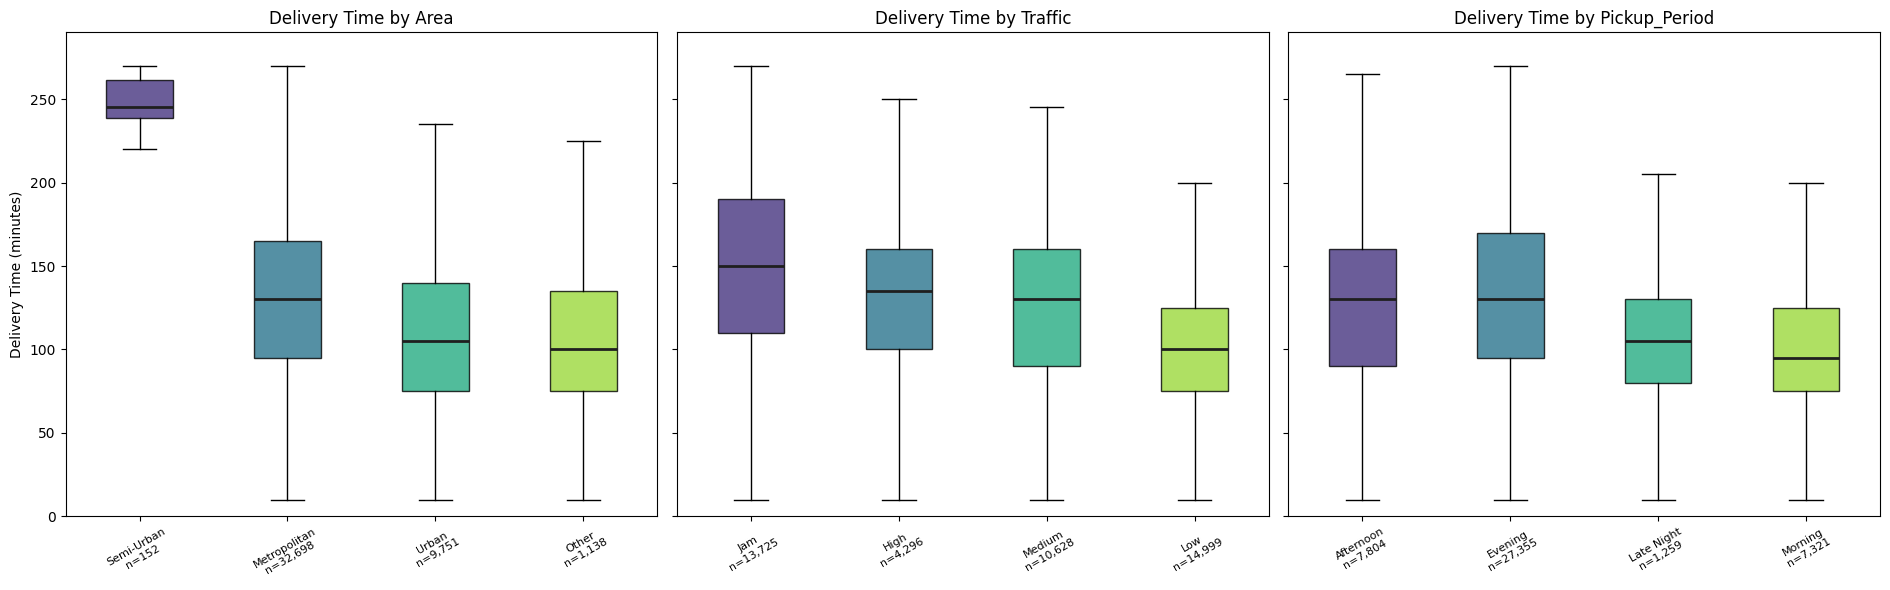

In [5]:
key_factors = ["Area", "Traffic", "Pickup_Period"]
fig, axes = plt.subplots(1, 3, figsize=(19, 6), sharey=True)

for axis, factor in zip(axes, key_factors):
    # Boxplots show the median, IQR, and wider distribution together.
    summary = group_summaries[factor]
    levels = summary.index.tolist()
    distributions = [
        df.loc[df[factor].eq(level), "Delivery_Time"].dropna().to_numpy()
        for level in levels
    ]
    labels = [f"{level}\nn={int(summary.loc[level, 'sample_size']):,}" for level in levels]
    boxplot = axis.boxplot(
        distributions,
        tick_labels=labels,
        showfliers=False,
        patch_artist=True,
        medianprops={"color": "#1F1F1F", "linewidth": 2},
    )
    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(levels)))
    for box, color in zip(boxplot["boxes"], colors):
        box.set_facecolor(color)
        box.set_alpha(0.8)
    axis.set_title(f"Delivery Time by {factor}")
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=30, labelsize=8)

axes[0].set_ylabel("Delivery Time (minutes)")
axes[0].set_ylim(0, 290)

plt.tight_layout()
plt.show()

### 圖表解讀

- **Area：** Semi-Urban 只有 152 筆，但中位配送時間約 245 分鐘，約 94.7% 屬於長時間配送。
- **Traffic：** Jam 的中位數約 150 分鐘，Low Traffic 約 100 分鐘；長時間配送比例約為 41.0% 與 6.0%。
- **Pickup Period：** Morning 的中位數約 95 分鐘，Evening 約 130 分鐘；長時間配送比例由約 5.2% 上升至 28.7%。

## 7. Semi-Urban Drill-down｜區域深入分析

### 7.1 分析範圍

Semi-Urban 共有 152 筆配送紀錄，這些紀錄都可用於 Area、Traffic、Pickup Period 與 Delivery Time 比較。不過，其中 14 筆的 Store 座標為 `(0, 0)`，無法可靠計算距離，因此距離表只使用其餘 138 筆有效座標紀錄。這 14 筆只排除於 Distance 分析，沒有從其他分析刪除。

### 7.2 圖表閱讀方式

- 左圖比較各 Area 內部的 Traffic 百分比組成，用來確認 Semi-Urban 是否特別集中於壅塞狀態。
- 中圖比較各 Area 內部的 Pickup Period 百分比組成，用來確認 Semi-Urban 是否集中於特定時段。
- 右圖只保留 Traffic = Jam 的紀錄，再比較各 Area 的中位配送時間，用來判斷交通組成是否足以解釋區域差異。

此步驟的目的不是證明原因，而是判斷 Distance、Traffic 或 Pickup Period 是否能充分解釋 Semi-Urban 的極端配送時間。

Distance vs. Delivery Time — Spearman rho: 0.285, p-value < 0.001


,valid_distance_records,median_distance_km,median_delivery_minutes
Area,,,
Semi-Urban,138,12.46,245.00
Metropolitan,29986,9.31,130.00
Other,1048,9.06,100.00
Urban,8874,7.79,105.00


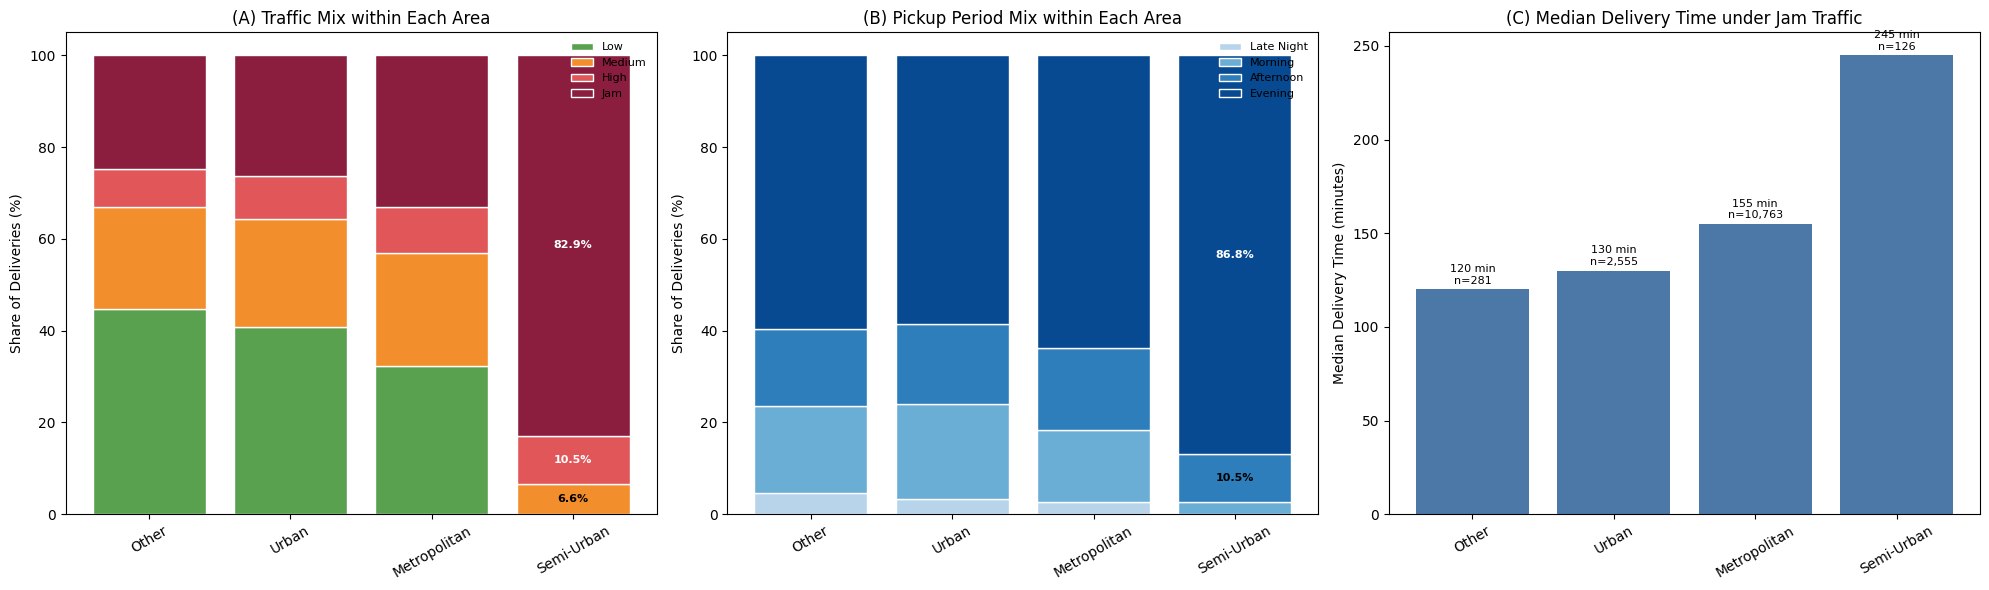

In [6]:
distance_analysis = df.dropna(subset=["Distance_km", "Delivery_Time"])
distance_test = spearmanr(distance_analysis["Distance_km"], distance_analysis["Delivery_Time"])
distance_by_area = (
    distance_analysis.groupby("Area")
    .agg(
        valid_distance_records=("Distance_km", "size"),
        median_distance_km=("Distance_km", "median"),
        median_delivery_minutes=("Delivery_Time", "median"),
    )
    .sort_values("median_distance_km", ascending=False)
)

area_traffic_mix = pd.crosstab(df["Area"], df["Traffic"], normalize="index").mul(100)
area_period_mix = pd.crosstab(df["Area"], df["Pickup_Period"], normalize="index").mul(100)
jam_area_comparison = (
    df.loc[df["Traffic"].eq("Jam")]
    .groupby("Area")
    .agg(sample_size=("Delivery_Time", "size"), median_minutes=("Delivery_Time", "median"))
    .sort_values("median_minutes", ascending=False)
)

print(f"Distance vs. Delivery Time — Spearman rho: {distance_test.statistic:.3f}, p-value < 0.001")
display(distance_by_area.round(2))

# Visualize composition and compare Areas under the same Jam condition.
area_order = ["Other", "Urban", "Metropolitan", "Semi-Urban"]
traffic_order = ["Low", "Medium", "High", "Jam"]
period_order = ["Late Night", "Morning", "Afternoon", "Evening"]
traffic_plot = area_traffic_mix.reindex(index=area_order, columns=traffic_order, fill_value=0)
period_plot = area_period_mix.reindex(index=area_order, columns=period_order, fill_value=0)
jam_plot = jam_area_comparison.reindex(area_order)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

bottom = np.zeros(len(traffic_plot))
traffic_colors = {"Low": "#59A14F", "Medium": "#F28E2B", "High": "#E15759", "Jam": "#8B1E3F"}
for level in traffic_order:
    axes[0].bar(traffic_plot.index, traffic_plot[level], bottom=bottom, label=level, color=traffic_colors[level], edgecolor="white")
    bottom += traffic_plot[level].to_numpy()
axes[0].set_title("(A) Traffic Mix within Each Area")
axes[0].set_ylabel("Share of Deliveries (%)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(frameon=False, fontsize=8)
semi_position = area_order.index("Semi-Urban")
semi_bottom = 0
for level in traffic_order:
    value = traffic_plot.loc["Semi-Urban", level]
    if value >= 5:
        axes[0].text(semi_position, semi_bottom + value / 2, f"{value:.1f}%", ha="center", va="center", color="white" if level in ["High", "Jam"] else "black", fontsize=8, fontweight="bold")
    semi_bottom += value

bottom = np.zeros(len(period_plot))
period_colors = dict(zip(period_order, plt.cm.Blues(np.linspace(0.3, 0.9, len(period_order)))))
for level in period_order:
    axes[1].bar(period_plot.index, period_plot[level], bottom=bottom, label=level, color=period_colors[level], edgecolor="white")
    bottom += period_plot[level].to_numpy()
axes[1].set_title("(B) Pickup Period Mix within Each Area")
axes[1].set_ylabel("Share of Deliveries (%)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(frameon=False, fontsize=8)
semi_bottom = 0
for level in period_order:
    value = period_plot.loc["Semi-Urban", level]
    if value >= 5:
        axes[1].text(semi_position, semi_bottom + value / 2, f"{value:.1f}%", ha="center", va="center", color="white" if level == "Evening" else "black", fontsize=8, fontweight="bold")
    semi_bottom += value

bars = axes[2].bar(jam_plot.index, jam_plot["median_minutes"], color="#4C78A8")
axes[2].set_title("(C) Median Delivery Time under Jam Traffic")
axes[2].set_ylabel("Median Delivery Time (minutes)")
axes[2].tick_params(axis="x", rotation=30)
for bar, sample_size in zip(bars, jam_plot["sample_size"]):
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3, f"{bar.get_height():.0f} min\nn={int(sample_size):,}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

### 7.3 本章結論

**觀察：** 在 138 筆有效距離紀錄中，Semi-Urban 的中位距離約為 12.5 公里，高於其他 Area 的約 7.8–9.3 公里；整體 Distance 與 Delivery Time 呈現正向但不強的關聯（Spearman rho 約 0.29）。在全部 152 筆 Semi-Urban 紀錄中，82.9% 為 Jam、沒有 Low Traffic，而且 86.8% 發生在 Evening。

**進一步比較：** 即使只比較 Jam 紀錄，Semi-Urban 的中位配送時間仍為 245 分鐘（n = 126），高於 Metropolitan 的 155 分鐘（n = 10,763）、Urban 的 130 分鐘（n = 2,555）與 Other 的 120 分鐘（n = 281）。

**解讀：** Semi-Urban 的距離稍長，而且資料集中在 Jam 與 Evening，這些都是值得追查的線索；但相同 Jam 條件下仍存在很大的區域差距，因此 Distance、Traffic 組成與 Pickup Period 都不足以單獨解釋結果。

**本章結論：** 現有證據支持將 Semi-Urban 設為優先調查區域，但不能將較長配送時間直接歸因於 Traffic 或 Evening。下一步應取得 route design、pickup waiting time、agent availability、訂單量與 dispatch 規則，確認未觀察到的區域流程是否造成差距。

## 8. 多變量分析

### 8.1 承接上一章：這一步要回答什麼？

上一章發現 Distance、Traffic 組成與 Pickup Period 都不足以單獨解釋 Semi-Urban 的配送時間差距，並指出下一步需要 route design、pickup waiting time、agent availability、訂單量與 dispatch 規則等資料。現有靜態資料沒有這些欄位，因此本章 **不能直接驗證未觀察到的區域流程**。

在取得新資料前，多變量分析先進行最後一道穩定性檢查：

1. 納入目前可觀察的 Area、Traffic、Pickup Period、Distance、Weather 與 Category 後，Semi-Urban 的差距是否仍然存在？
2. 哪些已觀察因素的關聯較穩定，哪些因素會因模型設定而改變方向？
3. 現有變數無法解釋的剩餘差距，是否足以支持優先蒐集 Semi-Urban 的 route 與 capacity 資料？

如果 Semi-Urban 的差距在納入其他因素後大幅消失，代表已觀察到的群組組成可能可以解釋問題；如果差距仍然很大，則支持把缺少的區域流程資料列為下一步調查重點，但仍不能證明這些未觀察因素就是原因。

### 8.2 模型設定

使用可解釋的線性回歸，同時納入 Area、Traffic、Pickup Period、Distance、Weather 與 Category。模型採用 HC3 robust standard errors，降低變異數不一致對信賴區間的影響。參考群組為 Other Area、Low Traffic、Morning、Sunny 與 Grocery。係數表示在納入其他已觀察因素後，該群組與參考群組的平均分鐘差異；它是調整後關聯，不是因果效果。

### 8.3 輸出與圖表閱讀方式

- 係數表列出估計分鐘差、HC3 standard error、95% confidence interval 與 p-value。
- 左圖呈現主要調整後係數與 95% confidence interval。Area、Traffic 與 Pickup Period 的正值代表相對參考群組具有較長的配送時間。Distance 是連續變數，模型原始係數代表每增加 1 公里的分鐘差；為了讓圖上的差距更容易閱讀，圖中改用每增加 5 公里呈現，約對應增加 11 分鐘。
- 中圖比較 Pickup Period 在「未納入 Traffic」與「納入 Traffic」兩種模型下的係數，用來檢查時段結論是否穩定。
- 右圖顯示實際存在的 Traffic × Pickup Period 樣本數；空白或 0 代表資料缺少該組合，模型難以可靠分離兩個因素。

Model records: 39,997
R-squared: 0.482; adjusted R-squared: 0.482


,term,coefficient,robust_se,ci_low,ci_high,p_value
1,Distance_km,2.20,0.04,2.12,2.29,< 0.001
2,Area_Urban,2.85,1.21,0.47,5.23,0.019
3,Area_Metropolitan,17.47,1.17,15.18,19.76,< 0.001
4,Area_Semi-Urban,102.04,3.03,96.11,107.98,< 0.001
5,Traffic_Medium,21.85,0.60,20.66,23.03,< 0.001
6,Traffic_High,36.11,0.81,34.53,37.69,< 0.001
7,Traffic_Jam,39.30,0.55,38.22,40.38,< 0.001
8,Pickup_Period_Late Night,-8.14,1.19,-10.47,-5.82,< 0.001
9,Pickup_Period_Afternoon,-8.57,0.81,-10.16,-6.98,< 0.001
10,Pickup_Period_Evening,-7.87,0.67,-9.18,-6.57,< 0.001


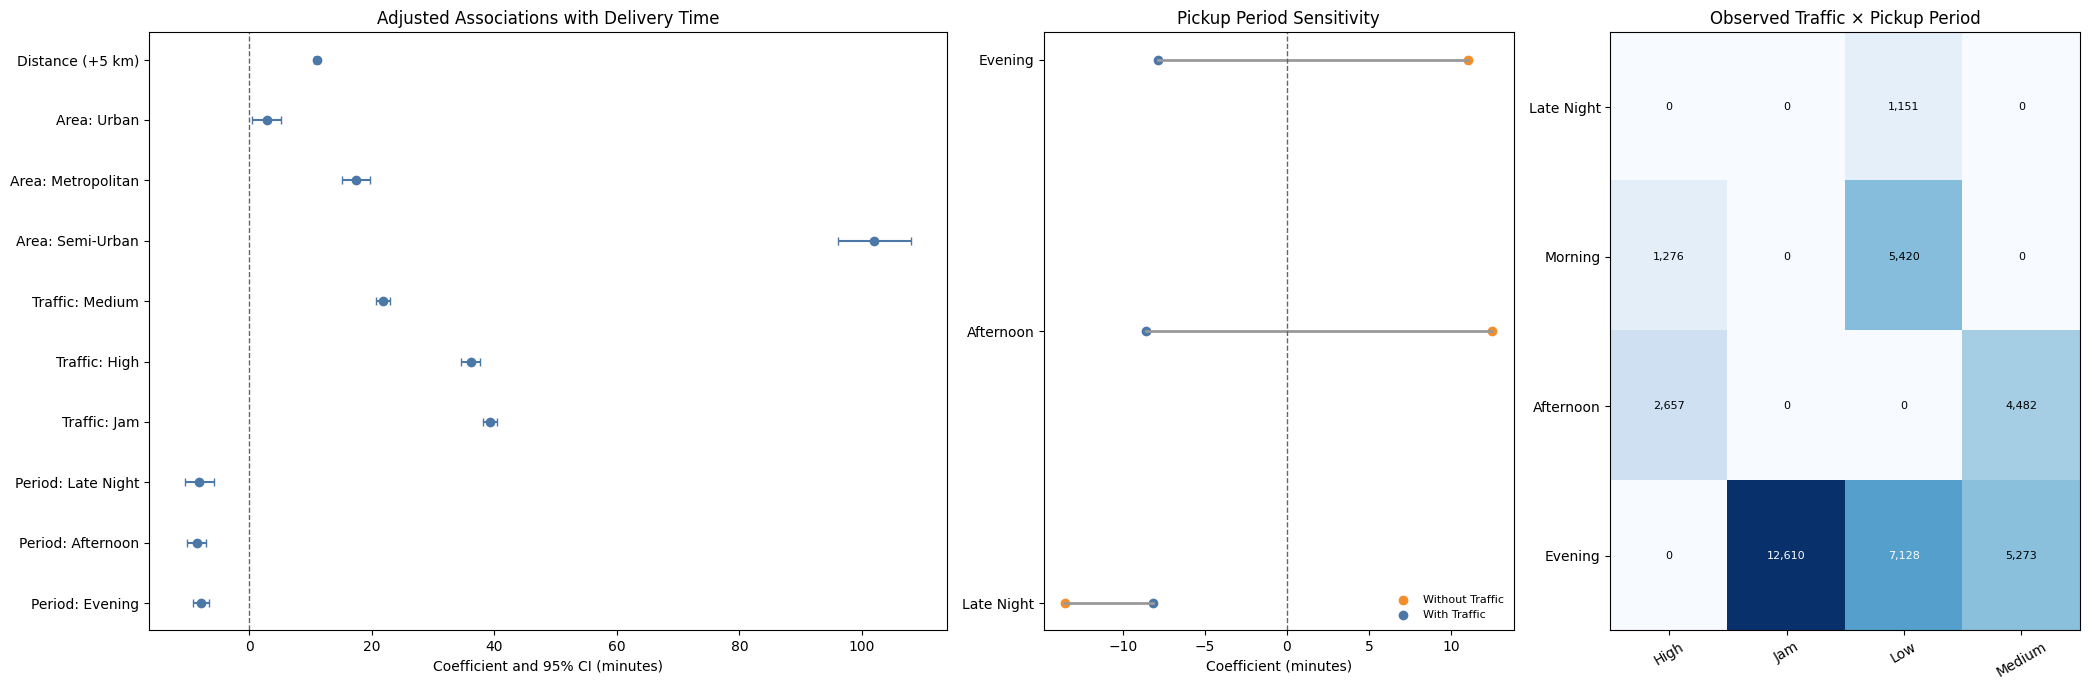

In [7]:
def fit_ols_hc3(model_data, predictors, categorical_orders):
    # Fit OLS and calculate HC3 heteroskedasticity-robust standard errors.
    categorical_columns = [column for column in categorical_orders if column in predictors]
    prepared = model_data[["Delivery_Time"] + predictors].copy()
    for column in categorical_columns:
        prepared[column] = pd.Categorical(
            prepared[column], categories=categorical_orders[column]
        )

    design = pd.get_dummies(
        prepared[predictors],
        columns=categorical_columns,
        drop_first=True,
        dtype=float,
    )
    design.insert(0, "Intercept", 1.0)
    x = design.to_numpy(dtype=float)
    y = prepared["Delivery_Time"].to_numpy(dtype=float)

    coefficients = np.linalg.lstsq(x, y, rcond=None)[0]
    fitted = x @ coefficients
    residuals = y - fitted
    xtx_inverse = np.linalg.pinv(x.T @ x)
    leverage = np.einsum("ij,jk,ik->i", x, xtx_inverse, x)
    adjusted_residuals = residuals / (1 - leverage)
    meat = x.T @ ((adjusted_residuals ** 2)[:, None] * x)
    covariance = xtx_inverse @ meat @ xtx_inverse
    robust_se = np.sqrt(np.diag(covariance))
    p_values = 2 * norm.sf(np.abs(coefficients / robust_se))

    total_ss = ((y - y.mean()) ** 2).sum()
    residual_ss = (residuals ** 2).sum()
    r_squared = 1 - residual_ss / total_ss
    adjusted_r_squared = 1 - (1 - r_squared) * (len(y) - 1) / (len(y) - len(coefficients))

    results = pd.DataFrame({
        "term": design.columns,
        "coefficient": coefficients,
        "robust_se": robust_se,
        "ci_low": coefficients - 1.96 * robust_se,
        "ci_high": coefficients + 1.96 * robust_se,
        "p_value": p_values,
    })
    metrics = {"records": len(y), "r_squared": r_squared, "adjusted_r_squared": adjusted_r_squared}
    return results, metrics


model_columns = [
    "Delivery_Time", "Distance_km", "Area", "Traffic",
    "Pickup_Period", "Weather", "Category",
]
model_data = df[model_columns].dropna().copy()
category_orders = {
    "Area": ["Other", "Urban", "Metropolitan", "Semi-Urban"],
    "Traffic": ["Low", "Medium", "High", "Jam"],
    "Pickup_Period": ["Morning", "Late Night", "Afternoon", "Evening"],
    "Weather": ["Sunny", "Windy", "Sandstorms", "Stormy", "Fog", "Cloudy"],
    "Category": ["Grocery"] + sorted(
        category for category in model_data["Category"].unique() if category != "Grocery"
    ),
}
full_predictors = ["Distance_km", "Area", "Traffic", "Pickup_Period", "Weather", "Category"]
full_results, full_metrics = fit_ols_hc3(model_data, full_predictors, category_orders)
no_traffic_results, _ = fit_ols_hc3(
    model_data, [column for column in full_predictors if column != "Traffic"], category_orders
)

key_terms = [
    "Distance_km", "Area_Urban", "Area_Metropolitan", "Area_Semi-Urban",
    "Traffic_Medium", "Traffic_High", "Traffic_Jam",
    "Pickup_Period_Late Night", "Pickup_Period_Afternoon", "Pickup_Period_Evening",
]
key_coefficients = full_results.loc[full_results["term"].isin(key_terms)].copy()
key_coefficients["p_value"] = key_coefficients["p_value"].map(
    lambda value: "< 0.001" if value < 0.001 else f"{value:.3f}"
)

period_terms = ["Pickup_Period_Late Night", "Pickup_Period_Afternoon", "Pickup_Period_Evening"]
period_sensitivity = (
    no_traffic_results.loc[no_traffic_results["term"].isin(period_terms), ["term", "coefficient"]]
    .rename(columns={"coefficient": "without_traffic"})
    .merge(
        full_results.loc[full_results["term"].isin(period_terms), ["term", "coefficient"]]
        .rename(columns={"coefficient": "with_traffic"}),
        on="term",
    )
)
traffic_period_overlap = pd.crosstab(model_data["Pickup_Period"], model_data["Traffic"])

print(f"Model records: {full_metrics['records']:,}")
print(f"R-squared: {full_metrics['r_squared']:.3f}; adjusted R-squared: {full_metrics['adjusted_r_squared']:.3f}")
display(key_coefficients.round(2))

# Plot adjusted coefficients, period sensitivity, and observed overlap.
coefficient_labels = {
    "Distance_km": "Distance (+5 km)",
    "Area_Urban": "Area: Urban",
    "Area_Metropolitan": "Area: Metropolitan",
    "Area_Semi-Urban": "Area: Semi-Urban",
    "Traffic_Medium": "Traffic: Medium",
    "Traffic_High": "Traffic: High",
    "Traffic_Jam": "Traffic: Jam",
    "Pickup_Period_Late Night": "Period: Late Night",
    "Pickup_Period_Afternoon": "Period: Afternoon",
    "Pickup_Period_Evening": "Period: Evening",
}
coefficient_plot = full_results.set_index("term").loc[key_terms].copy()
coefficient_plot.loc["Distance_km", ["coefficient", "ci_low", "ci_high"]] *= 5
coefficient_plot["label"] = [coefficient_labels[term] for term in coefficient_plot.index]
coefficient_plot = coefficient_plot.iloc[::-1]

fig, axes = plt.subplots(1, 3, figsize=(21, 7), gridspec_kw={"width_ratios": [1.7, 1, 1]})
y_positions = np.arange(len(coefficient_plot))
axes[0].errorbar(
    coefficient_plot["coefficient"],
    y_positions,
    xerr=[
        coefficient_plot["coefficient"] - coefficient_plot["ci_low"],
        coefficient_plot["ci_high"] - coefficient_plot["coefficient"],
    ],
    fmt="o",
    color="#4C78A8",
    ecolor="#4C78A8",
    capsize=3,
)
axes[0].axvline(0, color="#666666", linestyle="--", linewidth=1)
axes[0].set_yticks(y_positions, coefficient_plot["label"])
axes[0].set_title("Adjusted Associations with Delivery Time")
axes[0].set_xlabel("Coefficient and 95% CI (minutes)")

period_labels = {
    "Pickup_Period_Late Night": "Late Night",
    "Pickup_Period_Afternoon": "Afternoon",
    "Pickup_Period_Evening": "Evening",
}
for position, row in period_sensitivity.reset_index(drop=True).iterrows():
    axes[1].plot([row["without_traffic"], row["with_traffic"]], [position, position], color="#999999", linewidth=2)
    axes[1].scatter(row["without_traffic"], position, color="#F28E2B", label="Without Traffic" if position == 0 else None)
    axes[1].scatter(row["with_traffic"], position, color="#4C78A8", label="With Traffic" if position == 0 else None)
axes[1].axvline(0, color="#666666", linestyle="--", linewidth=1)
axes[1].set_yticks(range(len(period_sensitivity)), [period_labels[term] for term in period_sensitivity["term"]])
axes[1].set_title("Pickup Period Sensitivity")
axes[1].set_xlabel("Coefficient (minutes)")
axes[1].legend(frameon=False, fontsize=8)

overlap_values = traffic_period_overlap.to_numpy()
image = axes[2].imshow(overlap_values, cmap="Blues", aspect="auto")
axes[2].set_xticks(range(len(traffic_period_overlap.columns)), traffic_period_overlap.columns, rotation=30)
axes[2].set_yticks(range(len(traffic_period_overlap.index)), traffic_period_overlap.index)
axes[2].set_title("Observed Traffic × Pickup Period")
for row_index in range(overlap_values.shape[0]):
    for column_index in range(overlap_values.shape[1]):
        value = overlap_values[row_index, column_index]
        text_color = "white" if value > overlap_values.max() * 0.55 else "black"
        axes[2].text(column_index, row_index, f"{value:,}", ha="center", va="center", color=text_color, fontsize=8)

plt.tight_layout()
plt.show()

### 8.4 結果解讀與本章結論

**觀察：** 模型使用 39,997 筆完整紀錄，可解釋約 48.2% 的 Delivery Time 變異。納入其他已觀察因素後：

- Semi-Urban 相對 Other 仍約高 **102 分鐘**，95% confidence interval 約為 96–108 分鐘。
- Jam 相對 Low Traffic 約高 **39 分鐘**；Distance 每增加 1 公里約與 **2.2 分鐘**增加相關，圖中每增加 5 公里約為 11 分鐘。
- 非 Grocery 類別相對 Grocery 約高 103–106 分鐘，支持 Grocery 可能屬於不同配送流程。
- Pickup Period 的方向在加入 Traffic 後反轉。資料中 Jam 只出現在 Evening，Late Night 只出現在 Low Traffic，因此缺乏足夠重疊來可靠分離 Traffic 與 Pickup Period。

**解讀：** Semi-Urban 的差距在納入現有欄位後仍然很大，表示 Distance、Traffic、Pickup Period、Weather 與 Category 的組成不足以解釋全部區域差異。但這個 Area 係數也可能吸收 route design、pickup waiting、agent availability、訂單量、dispatch 規則或其他未觀察因素，不能解讀為 Semi-Urban 本身造成額外 102 分鐘。Pickup Period 的係數不穩定，也說明原始群組平均差距不適合直接轉成 staffing 建議。

**本章結論：** 綜合以上結果，Semi-Urban 應作為下一步營運診斷的優先區域。具體調查項目、行動建議與分析限制將在下一章說明。

## 9. Recommendation and Limitations｜建議與限制

### 9.1 從分析證據到決策

| 分析證據 | 代表意義 | 對決策的影響 |
|---|---|---|
| 沒有 SLA 或 promised ETA | 只能衡量配送耗時，不能判定逾期 | 使用 Delivery Time、median、P75 與長時間配送比例衡量改善 |
| Semi-Urban 的中位數為 245 分鐘，94.7% 超過 160 分鐘 | 問題集中且差距具有營運意義 | 將 Semi-Urban 設為第一診斷優先區域 |
| Distance 稍長，且 Jam、Evening 比例偏高 | 這些因素可能相關 | 保留為調查線索，但不能直接視為原因 |
| 相同 Jam 條件下，Semi-Urban 仍明顯較慢 | Traffic 組成不足以解釋區域差距 | 需要調查區域流程與未觀察因素 |
| 多變量模型中 Semi-Urban 仍約高 102 分鐘 | 現有欄位無法解釋全部差距 | 優先補充 route、waiting、capacity 與 dispatch 資料 |
| Pickup Period 的係數對是否納入 Traffic 很敏感 | 時段效果不穩定 | 暫不依時段平均直接調整 staffing |

### 9.2 建議

#### 1. 先做 Semi-Urban 的針對性流程診斷

目前最合理的行動不是全面增加資源，也不是改變 Semi-Urban 的訂單量或配送分配，而是優先補齊自然發生之 Semi-Urban 配送的流程紀錄，並同步保留其他 Area 作為比較。診斷應將總配送時間拆成可以行動的階段：等待派單、前往 pickup、pickup waiting、實際行駛與交付；若樣本仍不足，再延長觀察期間。

#### 2. 補充能區分可能原因的資料

| 可能問題 | 需要補充的資料 | 可以支持的決策 |
|---|---|---|
| Route bottleneck | route ID、planned/actual path、分路段 travel time | 是否調整路線或配送範圍 |
| Pickup delay | 到店時間、商品 ready time、完成 pickup 時間 | 是否改善備貨或取貨流程 |
| Capacity shortage | 各時段訂單量、active agents、agent utilization | 是否增加或重新配置運能 |
| Dispatch issue | assignment time、派單規則、batch size、reassignment | 是否調整派單邏輯 |
| 服務結果與成本 | promised ETA、完成時間、cost per delivery | 是否同時改善時間、準時率與成本 |

#### 3. 先確認 Grocery 是否屬於不同流程

Grocery 的配送時間與其他類別明顯不同。若它使用不同 fulfillment 或 delivery process，後續診斷與模型應分層進行，避免 Grocery 改變整體比較基準。

#### 4. 取得診斷證據後，再選擇改善措施

如果差距主要來自 travel time，優先測試 route 調整；如果來自 pickup waiting，改善備貨與交接；如果來自 orders-to-agents imbalance，再調整 staffing；如果來自 assignment delay，則測試 dispatch 規則。這能避免在原因不明時直接全面增加運能。

#### 5. 使用小規模驗證決定是否擴大

在不改變訂單量與配送分配的前提下，針對自然發生且符合條件的 Semi-Urban 配送試行小規模 route、pickup、capacity 或 dispatch 調整，並保留未調整的相似配送作為比較。主要觀察 Delivery Time median、P75 與長時間配送比例；若未來取得 SLA，再加入 on-time rate，同時以 cost per delivery 作為 guardrail。

這裡的「擴大」是逐步增加有效措施的適用範圍，不是增加配送量，例如：

- Route 調整：從少數測試路線擴展到其他具有相似瓶頸的路線。
- Pickup 改善：從部分 Store 擴展到其他 pickup waiting time 較長的 Store。
- Capacity 調整：從特定班次擴展到其他具有相似 orders-to-agents imbalance 的班次。
- Dispatch 規則：從少數 agent 或路線擴展到其他符合相同條件的配送。

只有在配送時間與長時間配送比例改善、成本可接受且其他服務指標沒有惡化時，才逐步擴大措施的適用範圍。

### 9.3 限制

- **資料用途：** 這是公開且靜態的觀察資料，不能證明因果關係，也不代表目前 Amazon 的實際營運。
- **時間範圍：** 資料只涵蓋 2022-02-11 至 2022-04-06 的 44 個日期，無法判斷季節性或長期穩定性。
- **KPI 限制：** 沒有 SLA 或 promised ETA，因此 160 分鐘只是分析門檻，不能解讀為逾期標準。
- **樣本限制：** Semi-Urban 只有 152 筆；距離分析因零原點座標只使用其中 138 筆；Jam 條件比較則使用其中 126 筆。
- **座標品質：** 全部資料中有 3,693 筆座標未通過距離分析規則，Distance 結果可能不代表所有配送紀錄。
- **資料重疊：** Jam 只出現在 Evening，Late Night 只出現在 Low Traffic，無法可靠分離 Traffic 與 Pickup Period 的獨立關聯。
- **缺少流程資料：** 沒有 route、pickup waiting、訂單量、agent availability、dispatch、promised ETA 與成本欄位，Area 係數可能吸收這些未觀察因素。
- **模型限制：** 線性回歸與 HC3 standard errors 只能描述調整後關聯，仍依賴線性、觀測獨立及模型設定等假設。

### 9.4 最終決策

**現在可以決定的事：** 將 Semi-Urban 設為第一資料蒐集與流程診斷區域。

**現在還不能決定的事：** 不能直接認定 Traffic、Evening、人力不足或路線設計是根因，也不應立即全面增加運能。

**下一個決策點：** 補充並拆解 Semi-Urban 的 route、waiting、capacity 與 dispatch 資料後，選擇對應的低風險改善措施，再以小規模測試決定是否擴大。

## Appendix｜附錄

### A. 為何使用 HC3 Robust Standard Errors

一般 OLS standard errors 假設不同紀錄的誤差變異大致相同，但本資料的群組樣本數與配送時間分布明顯不平衡。例如 Semi-Urban 只有 152 筆，而 Metropolitan 超過三萬筆；Grocery 的配送時間分布也與其他商品類別明顯不同。因此，等變異假設可能不成立。

HC3 允許不同紀錄具有不同的誤差變異，並對高 leverage 的觀測值採取較保守的修正，使 standard errors、confidence intervals 與 p-values 較不容易過度樂觀。HC3 不會改變回歸係數、預測值或 R-squared，也不會讓觀察資料變成因果證據。

HC3 仍假設各筆紀錄彼此獨立，不能處理同一路線、城市或日期內可能存在的群聚相關。如果未來取得 route、city 或其他群組識別欄位，應進一步考慮 clustered standard errors 或 multilevel model。

### B. 完整群組統計

下表保留 Area、Traffic 與 Pickup Period 的完整樣本數、平均數、中位數、IQR 與長時間配送比例，供需要核對圖表數值時使用。

In [8]:
key_group_results = pd.concat(
    {factor: group_summaries[factor] for factor in key_factors},
    names=["factor", "level"],
)
display(key_group_results.round(2))

sample_size  mean_minutes  median_minutes  \
factor        level                                                     
Area          Semi-Urban            152        238.55          245.00   
              Metropolitan        32698        129.70          130.00   
              Urban                9751        109.43          105.00   
              Other                1138        104.46          100.00   
Traffic       Jam                 13725        147.76          150.00   
              High                 4296        129.42          135.00   
              Medium              10628        126.84          130.00   
              Low                 14999        101.35          100.00   
Pickup_Period Afternoon            7804        125.96          130.00   
              Evening             27355        132.24          130.00   
              Late Night           1259        106.00          105.00   
              Morning              7321         99.62           95.00   

                            q1_minutes  q3_minutes  long_duration_rate  
factor        level                                                     
Area          Semi-Urban        238.75      261.25               94.74  
              Metropolitan       95.00      165.00               25.85  
              Urban              75.00      140.00               13.92  
              Other              75.00      135.00               11.42  
Traffic       Jam               110.00      190.00               41.01  
              High              100.00      160.00               22.84  
              Medium             90.00      160.00               24.05  
              Low                75.00      125.00                6.03  
Pickup_Period Afternoon          90.00      160.00               22.07  
              Evening            95.00      170.00               28.72  
              Late Night         80.00      130.00                9.77  
              Morning            75.00      125.00                5.25